In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

df = pd.read_csv("customer_shopping_behavior.csv")

In [4]:
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.shape

(3900, 18)

In [6]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
df.describe(include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [9]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [11]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform( lambda x : x.fillna(x.median()))  

In [12]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [16]:
df = df.rename(columns = {'purchase_amount_(usd)' : 'purchase_amount'})

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [18]:
bins = [17, 25, 35, 45, 55, 100]

labels = [
    'Young Adult',
    'Adult',
    'Middle Age',
    'Senior Adult',
    'Senior'
]

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [19]:
df[['age','age_group']].head()

,age,age_group
0,55,Senior Adult
1,19,Young Adult
2,50,Senior Adult
3,21,Young Adult
4,45,Middle Age


In [20]:
frequency_mapping =  {
    'Weekly' : 7,
    'Fortnightly' : 14,
    'Bi-Weekly':14,
    'Annually' : 365,
    'Monthly': 30,
    'Every 3 Months' : 90,
    'Quarterly' : 90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [21]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [22]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [23]:
df = df.drop('promo_code_used',axis=1)

In [24]:
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [25]:
df['customer_segment'] = np.where(
    df['previous_purchases'] == 1,
    'New',
    np.where(
        df['previous_purchases'] <= 10,
        'Returning',
        'Loyal'
    )
)

In [26]:
df[['previous_purchases', 'customer_segment']].head(10)

,previous_purchases,customer_segment
0,14,Loyal
1,2,Returning
2,23,Loyal
3,49,Loyal
4,31,Loyal
5,14,Loyal
6,49,Loyal
7,19,Loyal
8,8,Returning
9,4,Returning


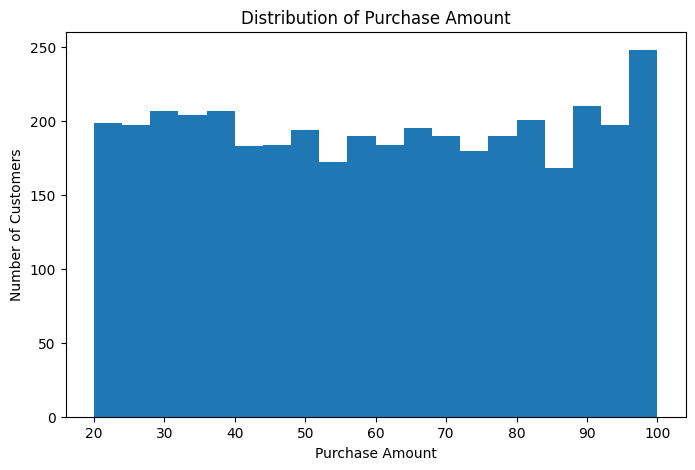

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['purchase_amount'], bins=20)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Customers")
plt.show()

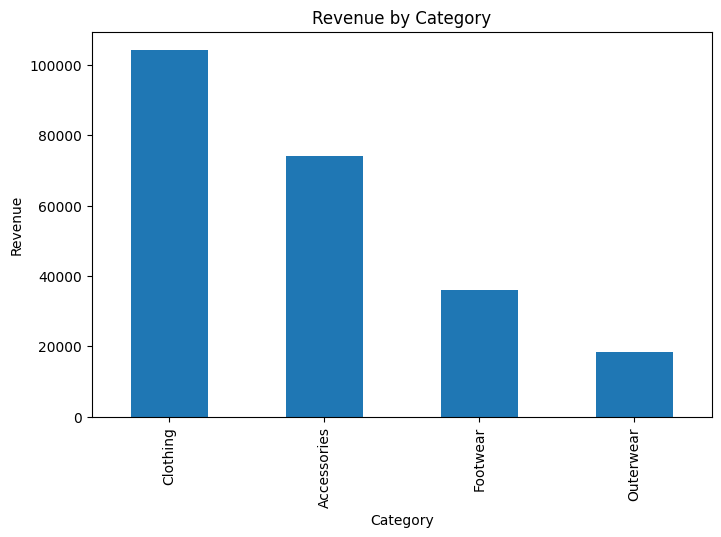

In [28]:
category_revenue = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

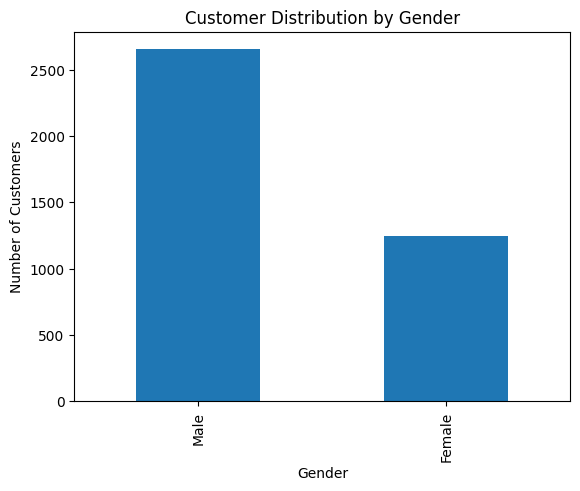

In [29]:
gender_count = df['gender'].value_counts()

gender_count.plot(kind='bar')

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

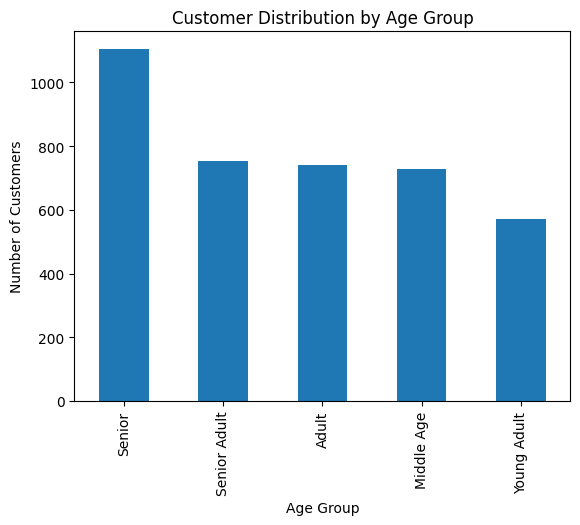

In [30]:
age_group_count = df['age_group'].value_counts()

age_group_count.plot(kind='bar')

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

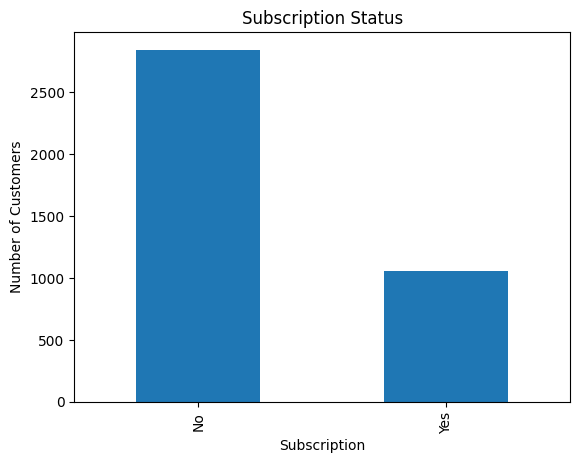

In [31]:
subscription_count = df['subscription_status'].value_counts()

subscription_count.plot(kind='bar')

plt.title("Subscription Status")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

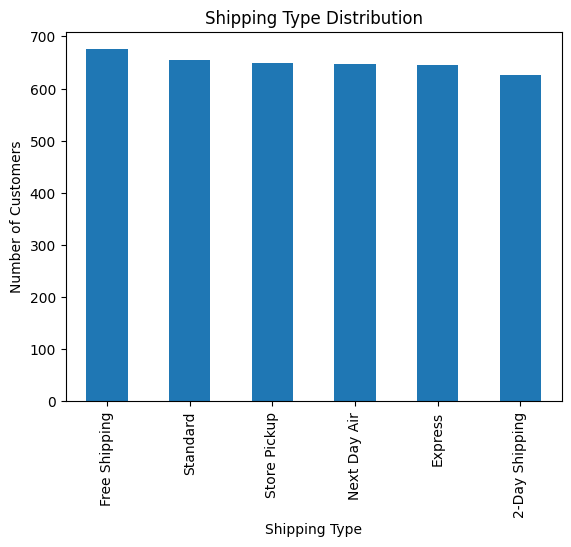

In [32]:
shipping_count = df['shipping_type'].value_counts()

shipping_count.plot(kind='bar')

plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Number of Customers")

plt.show()

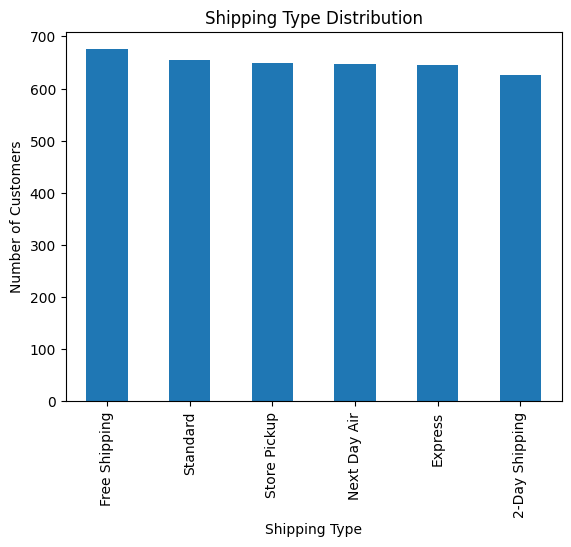

In [33]:
shipping_count = df['shipping_type'].value_counts()

shipping_count.plot(kind='bar')

plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
pip install psycopg2-binary sqlalchemy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres"
password = quote_plus("Khushman@1")
host = "localhost"
port = "5432"
database = "customer_behaviour"  # ✅ corrected

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

engine.connect()

In [36]:
table_name = "customer"
df.to_sql(table_name, engine, if_exists='replace', index=False)
print("Data successfully loaded 🚀")

Data successfully loaded 🚀


In [38]:
df.to_csv("customer_cleaned2.csv", index=False)